In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
df = pd.read_csv('HousingData.csv')

In [21]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.980000,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.140000,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.030000,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.940000,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,12.715432,36.2


In [22]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [23]:
df = df.fillna(df.mean())

In [24]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [11]:
#independent variable
x=df.drop("MEDV",axis=1)

#dependent varibale
y=df["MEDV"]

In [12]:
print(x.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B      LSTAT  
0  396.90   4.980000  
1  396.90   9.140000  
2  392.83   4.030000  
3  394.63   2.940000  
4  396.90  12.715432  


In [13]:
print(y.head())

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64


In [25]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Predictions:", y_pred)

Predictions: [25.2716091  14.73151804 15.37941509 21.01378656 15.68674414 14.89853971
 24.2692817  25.1468784  22.71498271 19.32847006 14.39559039 31.61445235
 16.70493548 13.78046805 13.61228093 34.43035161 15.43103215 22.45088901
 21.08633135 20.87267088 23.36354544 10.24496534 23.53931461 19.37996783
 21.59357853 34.32034824 36.5203158  16.53043017 29.2609638  21.01965335
 17.39669008 25.15656877 25.60264373 14.47201681 40.72318447 25.93515567
 25.4405247  20.61094648 31.04800572 16.1449699  16.08627803  9.12311213
 32.67598375 13.65861123 15.21516723 14.46908294 14.34969311 18.29236729
 24.04293    20.93275129 24.11276943 23.00660852 28.5357689  23.57854484
 20.22068504 21.64720494 40.44951108 16.80374841  7.54646275 19.85649553
 13.51187701 24.30843284 40.89466552 24.83665635 21.11253102 35.0453278
 21.42856362 29.65385192 34.61627742 13.74247613 16.90076592 33.67754818
 23.29942399 12.32239526 24.35551063 22.38049798 28.45627166 35.10397157
 17.7809965  13.57790805 24.29799016 23

In [15]:
result = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(result.head())

     Actual  Predicted
312    19.4  22.900356
14     18.2  19.464819
454    14.9  16.456671
156    13.1  12.797456
484    20.6  19.800513


In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [17]:
print("MSE:", mse)


MSE: 21.597358992890697


In [18]:
print("R2 Score:", r2)


R2 Score: 0.7039828020929467


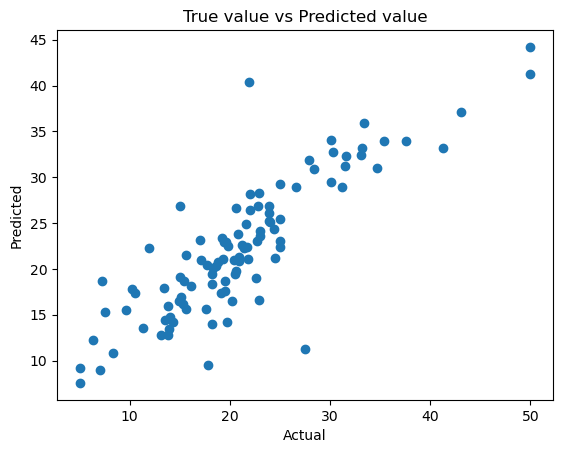

In [19]:
plt.scatter(y_test, y_pred)
plt.title("True value vs Predicted value")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


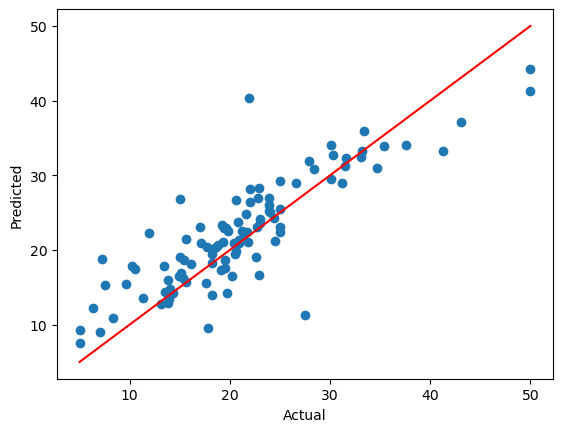

In [20]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("actual vs predicted")
plt.show()
